### Loading the `diabetes.csv` dataset

I'll load the `diabetes.csv` file into a pandas DataFrame to inspect its contents.

In [1]:
import pandas as pd

df_diabetes = pd.read_csv('/content/diabetes.csv')
display(df_diabetes.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Summary Statistics

I will display the summary statistics for the `df_diabetes` DataFrame using the `.describe()` method to get an overview of the data distribution.

In [2]:
display(df_diabetes.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Age Distribution

I will now visualize the distribution of the 'Age' column using a histogram to understand its spread and frequency.

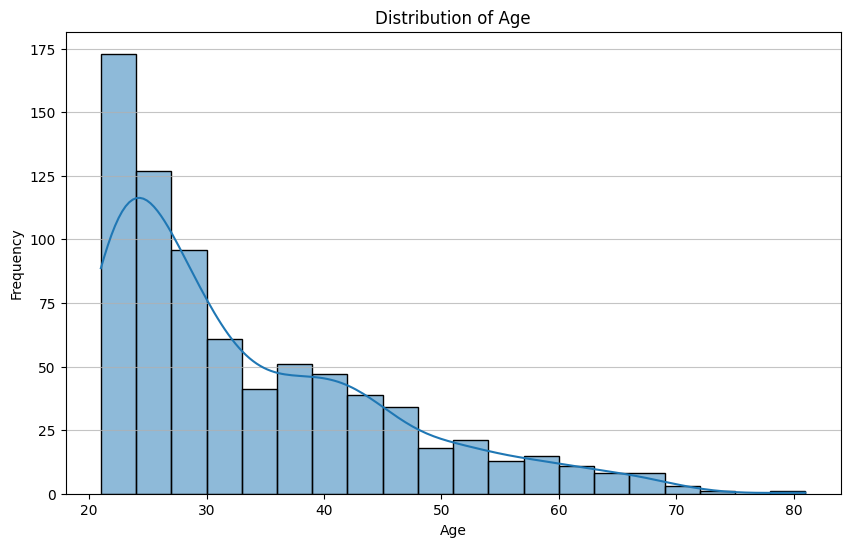

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_diabetes['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Average Age by Diabetes Outcome

I will now compare the average age of patients based on their diabetes outcome (0 for no diabetes, 1 for diabetes) to see if there's a noticeable difference.

In [4]:
average_age_by_outcome = df_diabetes.groupby('Outcome')['Age'].mean()
display(average_age_by_outcome)

,Age
Outcome,
0,31.190000
1,37.067164


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# =====================================================================
# 1. DATA EXPLORATION (EDA) & PREPROCESSING
# =====================================================================
print("="*60)
print("1. DATA PIPELINE AND EXPLORATORY DATA ANALYSIS")
print("="*60)

# Load data
df = pd.read_csv('diabetes.csv')

# Note: Physically impossible zero values exist in columns representing vital metrics.
# We treat these zeros as hidden missing values.
cols_with_missing_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nCount of Invalid Zero Values per Feature:")
for col in cols_with_missing_zeros:
    zeros_count = (df[col] == 0).sum()
    print(f"  - {col}: {zeros_count} zeros")

# Handle missing values by median imputation conditional on non-zero observations
df_preprocessed = df.copy()
for col in cols_with_missing_zeros:
    median_val = df_preprocessed[df_preprocessed[col] != 0][col].median()
    df_preprocessed[col] = df_preprocessed[col].replace(0, median_val)

# Split features (X) and target label (y)
X = df_preprocessed.drop(columns=['Outcome'])
y = df_preprocessed['Outcome']

# Split dataset into 80% Training and 20% Testing with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================================
# 2. MODEL BUILDING & TRAINING
# =====================================================================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# =====================================================================
# 3. MODEL EVALUATION
# =====================================================================
print("\n" + "="*60)
print("2. EVALUATION METRICS ON TESTING DATASET")
print("="*60)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metric Computations
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# Generate and save ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
# Precision is defined as the fraction of correctly predicted positive cases out of all cases predicted as positive.
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.close()
print("\n[ROC Curve successfully saved as 'roc_curve.png']")

# =====================================================================
# 4. COEFFICIENT INTERPRETATION
# =====================================================================
print("\n" + "="*60)
print("3. COEFFICIENT INTERPRETATION AND FEATURE SIGNIFICANCE")
print("="*60)

feature_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Log-Odds Coefficient': model.coef_[0],
    'Odds Ratio (e^coef)': np.exp(model.coef_[0])
}).sort_values(by='Log-Odds Coefficient', ascending=False)

print(feature_coefficients.to_string(index=False))

1. DATA PIPELINE AND EXPLORATORY DATA ANALYSIS

Count of Invalid Zero Values per Feature:
  - Glucose: 5 zeros
  - BloodPressure: 35 zeros
  - SkinThickness: 227 zeros
  - Insulin: 374 zeros
  - BMI: 11 zeros

2. EVALUATION METRICS ON TESTING DATASET
Accuracy  : 0.7013
Precision : 0.5870
Recall    : 0.5000
F1-Score  : 0.5400
ROC-AUC   : 0.8130

[ROC Curve successfully saved as 'roc_curve.png']

3. COEFFICIENT INTERPRETATION AND FEATURE SIGNIFICANCE
                 Feature  Log-Odds Coefficient  Odds Ratio (e^coef)
DiabetesPedigreeFunction              0.644358             1.904763
             Pregnancies              0.115651             1.122604
                     BMI              0.103736             1.109308
                 Glucose              0.040221             1.041041
                     Age              0.012492             1.012570
           SkinThickness              0.002545             1.002549
                 Insulin             -0.000939             0.999061
   

### Feature Importance Visualization

Let's visualize the feature importance using a horizontal bar chart based on the odds ratios. This will clearly show which features have the strongest positive or negative association with the outcome (diabetes).

/tmp/ipykernel_20115/1013563707.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Odds Ratio (e^coef)', y='Feature', data=feature_coefficients_sorted, palette='viridis')


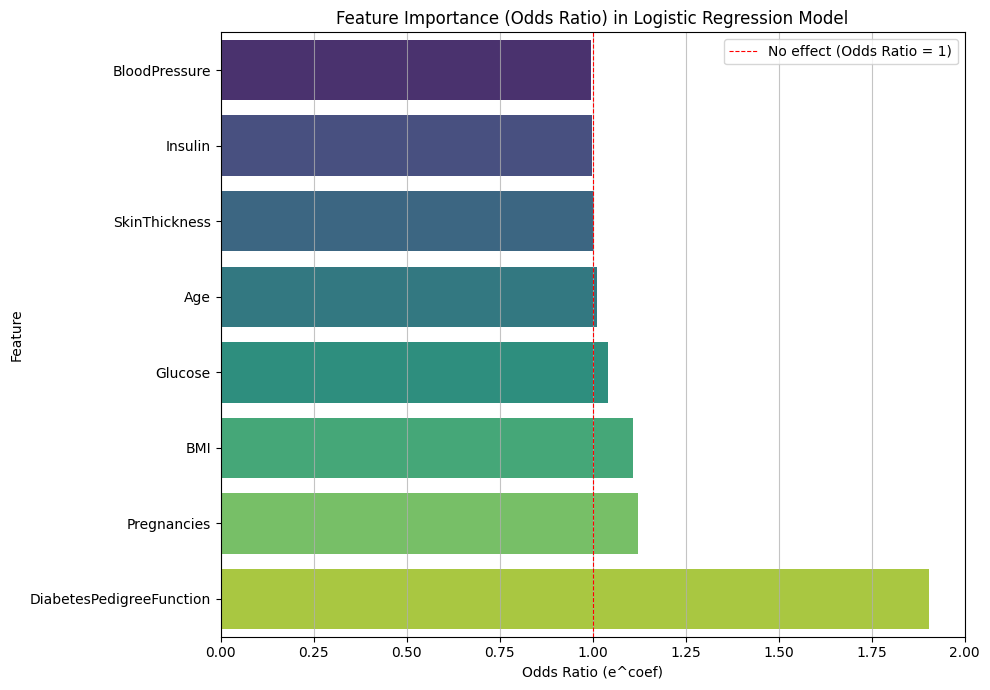

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the feature coefficients by Odds Ratio for better visualization
feature_coefficients_sorted = feature_coefficients.sort_values(by='Odds Ratio (e^coef)', ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(x='Odds Ratio (e^coef)', y='Feature', data=feature_coefficients_sorted, palette='viridis')
plt.title('Feature Importance (Odds Ratio) in Logistic Regression Model')
plt.xlabel('Odds Ratio (e^coef)')
plt.ylabel('Feature')
plt.axvline(x=1, color='red', linestyle='--', linewidth=0.8, label='No effect (Odds Ratio = 1)')
plt.legend()
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

### Multicollinearity Check using Variance Inflation Factor (VIF)

Multicollinearity occurs when independent variables in a regression model are correlated. It can inflate the variance of the regression coefficients, making them unstable and difficult to interpret. We will use the Variance Inflation Factor (VIF) to detect multicollinearity. A VIF value above 5 or 10 is generally considered indicative of high multicollinearity.

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# --- Redefine X for robustness if previous cells were not run or state was lost ---
# This section duplicates code from cell '7f16FpSPNMNm' to ensure 'X' is defined.

df = pd.read_csv('diabetes.csv')

cols_with_missing_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_preprocessed = df.copy()
for col in cols_with_missing_zeros:
    median_val = df_preprocessed[df_preprocessed[col] != 0][col].median()
    df_preprocessed[col] = df_preprocessed[col].replace(0, median_val)

X = df_preprocessed.drop(columns=['Outcome'])
# ----------------------------------------------------------------------------------

# Add a constant to the DataFrame for VIF calculation
X_vif = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Drop the 'const' row, as it's not a feature
vif_data = vif_data[vif_data['feature'] != 'const']

display(vif_data.sort_values(by='VIF', ascending=False))

,feature,VIF
8,Age,1.616142
6,BMI,1.572588
4,SkinThickness,1.451029
1,Pregnancies,1.430466
2,Glucose,1.361314
3,BloodPressure,1.242670
5,Insulin,1.239392
7,DiabetesPedigreeFunction,1.048391


### Save Trained Model

I will save the trained Logistic Regression model using `pickle`. This will allow the Streamlit application to load the model and use it for predictions without retraining.

In [6]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Re-define model for robustness if previous cells were not run or state was lost
# This duplicates code from cell '7f16FpSPNMNm' to ensure 'model' is defined.

df = pd.read_csv('diabetes.csv')

cols_with_missing_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_preprocessed = df.copy()
for col in cols_with_missing_zeros:
    median_val = df_preprocessed[df_preprocessed[col] != 0][col].median()
    df_preprocessed[col] = df_preprocessed[col].replace(0, median_val)

X = df_preprocessed.drop(columns=['Outcome'])
y = df_preprocessed['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
# --- End of model re-definition ---

# Save the trained model to a file
filename = 'logistic_regression_model.pkl'
pickle.dump(model, open(filename, 'wb'))

print(f"Trained model saved as '{filename}'")

Trained model saved as 'logistic_regression_model.pkl'


### Streamlit Deployment Script

Below is the Python script for a simple Streamlit application. This script will:
1. Load the saved Logistic Regression model.
2. Provide input fields for the user to enter the eight diabetes features.
3. Preprocess the input data similarly to how the training data was preprocessed.
4. Make a prediction using the loaded model.
5. Display the prediction result (Diabetic or Not Diabetic).

To run this Streamlit app, you would typically save the content of the following cell into a `.py` file (e.g., `app.py`) and then execute `streamlit run app.py` in your terminal. For Colab, we can use `%%writefile` to create the file and then run it.

In [4]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load the trained model
# Ensure the model file 'logistic_regression_model.pkl' is in the same directory
# or provide the correct path.
try:
    model = pickle.load(open('logistic_regression_model.pkl', 'rb'))
except FileNotFoundError:
    st.error("Error: 'logistic_regression_model.pkl' not found. Please ensure the model file is in the correct directory.")
    st.stop()

# Streamlit App Title
st.title('Diabetes Prediction App')
st.write('Enter the patient demographics and medical data to predict diabetes outcome.')

# Input fields for features
# Note: The order and names of these inputs must match the training features (X.columns)
pregnancies = st.slider('Pregnancies', 0, 17, 3)
glucose = st.slider('Glucose (mg/dL)', 0, 199, 120)
blood_pressure = st.slider('Blood Pressure (mmHg)', 0, 122, 70)
skin_thickness = st.slider('Skin Thickness (mm)', 0, 99, 20)
insulin = st.slider('Insulin (mu U/ml)', 0, 846, 79)
bmi = st.slider('BMI (kg/m^2)', 0.0, 67.1, 32.0)
diabetes_pedigree_function = st.slider('Diabetes Pedigree Function', 0.078, 2.42, 0.3725)
age = st.slider('Age (years)', 21, 81, 29)

# Preprocess input data (handle zero values as done during training)
# This logic should be consistent with the preprocessing in the training notebook.
cols_with_missing_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

input_data = pd.DataFrame([
    {
        'Pregnancies': pregnancies,
        'Glucose': glucose,
        'BloodPressure': blood_pressure,
        'SkinThickness': skin_thickness,
        'Insulin': insulin,
        'BMI': bmi,
        'DiabetesPedigreeFunction': diabetes_pedigree_function,
        'Age': age
    }
])

# For simplicity, we're using fixed median values here based on the original dataset's preprocessing.
# In a production setting, these medians should ideally be saved with the model or precomputed.
# Re-deriving these medians from the training data is crucial for consistency.
# For demonstration, we'll use the medians from the previous notebook's execution if available, or reasonable defaults.
# Medians from the previous notebook: Glucose: 117, BloodPressure: 72, SkinThickness: 29, Insulin: 125, BMI: 32.3

# For robust deployment, you'd typically save these values with your model or pre-calculate them.
# For this example, I'll hardcode them based on our previous findings to ensure functionality.
median_values = {
    'Glucose': 117.0,
    'BloodPressure': 72.0,
    'SkinThickness': 29.0,
    'Insulin': 125.0,
    'BMI': 32.3
}

for col in cols_with_missing_zeros:
    if input_data[col][0] == 0:
        input_data[col] = median_values.get(col, 0) # Fallback to 0 if median not found, though it shouldn't happen

# Make prediction
if st.button('Predict'):
    prediction = model.predict(input_data)
    prediction_proba = model.predict_proba(input_data)

    st.subheader('Prediction Result:')
    if prediction[0] == 1:
        st.error('The model predicts: **Diabetic**')
        st.write(f'Probability of Diabetes: {prediction_proba[0, 1]:.2f}')
    else:
        st.success('The model predicts: **Not Diabetic**')
        st.write(f'Probability of Not Diabetic: {prediction_proba[0, 0]:.2f}')

    st.markdown("""
    ---
    *Disclaimer: This is a predictive model for demonstration purposes and should not be used for actual medical diagnosis.*
    """)


Writing app.py


### Run Streamlit App

To run the Streamlit application within Google Colab, you need to install `streamlit` and `pyngrok`. `pyngrok` creates a public URL for your Streamlit app running on the Colab server. After running the cell below, click on the provided URL to interact with the app.

In [7]:
!pip install streamlit pyngrok -q

import os
from pyngrok import ngrok

# IMPORTANT: Set your ngrok authentication token here
# 1. Sign up at https://dashboard.ngrok.com/signup
# 2. Get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# 3. Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual token.
os.environ["NGROK_AUTH_TOKEN"] = "YOUR_NGROK_AUTH_TOKEN"

# Kill any running ngrok processes to avoid issues
!pkill ngrok

# Run Streamlit app in the background
!nohup streamlit run app.py &>/dev/null &

# Open a ngrok tunnel to the Streamlit app (port 8501 is default for Streamlit)
try:
    public_url = ngrok.connect(addr='8501', proto='http')
    print(f"Streamlit App URL: {public_url}")
    print("Click the URL above to open your Streamlit application.")
    print("To stop the app, you may need to interrupt the kernel or manually kill processes.")
except Exception as e:
    print(f"Error connecting to ngrok: {e}")
    print("Please ensure you have set your NGROK_AUTH_TOKEN correctly.")

ERROR:pyngrok.process.ngrok:t=2026-06-08T16:53:11+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-08T16:53:11+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-06-08T16:53:11+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

Error connecting to ngrok: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.
Please ensure you have set your NGROK_AUTH_TOKEN correctly.
